In [ ]:
!pip install statsmodels

In [ ]:
!pip install seaborn

In [7]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Set a random seed for reproducibility
np.random.seed(42)  # Answer to Life, the Universe, and Everything

In [8]:
# Number of participants
n = 100

In [9]:
# Define the questions and their stats for Perceived Usefulness (PU)
pu_items = {
    'valuable': (4.11, 4.0, 0.983654),
    'useful': (4.17, 4.0, 0.974990),
    'improve_efficiency': (4.08, 4.0, 0.981444),
    'better_decisions': (4.17, 4.0, 0.910711),
    'recommend': (4.32, 5.0, 0.863163) 
}
# Note: 'frequent_use' is our Intention to Use (ITU) variable, so it's separate.
itu_mean, itu_median, itu_std = (4.03, 4.0, 1.058444)

In [11]:
# --------------------------------------------------------------------
# Step 1: Generate synthetic data that matches the provided statistics
# We'll use a normal distribution. For a more precise simulation, you could use
# the Johnson SU distribution or others, but this is a good approximation.
# --------------------------------------------------------------------

# data = {}
# # Generate data for each PU item
# for item, (m, med, s) in pu_items.items():
#     # Generate data from a normal distribution, then clip to plausible bounds (1-5)
#     data[item] = np.clip(np.random.normal(loc=m, scale=s, size=n), 1, 5)

# # Generate data for the Intention to Use (ITU) variable
# data['frequent_use'] = np.clip(np.random.normal(loc=itu_mean, scale=itu_std, size=n), 1, 5)

# Create DataFrame
df = pd.read_csv('/home/vsingh/projects/chi-26/Evaluation/eval-phase2-questions.csv')
# Define the mapping of old column names to new column names
column_name_mapping = {
    'The tool would be valuable for my day-to-day HR tasks.': 'valuable',
    'The tool\'s features are useful and relevant to my professional responsibilities.': 'useful',
    'The tool would improve the efficiency of my work.': 'improve_efficiency',
    'The tool would help me make better decisions.': 'better_decisions',
    'I would use this tool frequently if it were available to me.': 'frequent_use',
    'I would recommend this tool to other HR Managers.': 'recommend'
}

# Apply the renaming to your DataFrame
df = df.rename(columns=column_name_mapping)

likert_map = {
    "Strongly disagree": 1,
    "Somewhat disagree": 2,
    "Neither agree nor disagree": 3,
    "Somewhat agree": 4,
    "Strongly agree": 5,}

df = df.replace(likert_map)
# Create the aggregate Perceived Usefulness (PU) score for each participant
df['PU'] = df[['valuable', 'useful', 'improve_efficiency', 'better_decisions', 'recommend']].mean(axis=1)
# Our Intention to Use (ITU) variable is already the 'frequent_use' column.
df['ITU'] = df['frequent_use']

/tmp/ipykernel_699242/4209208702.py:38: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(likert_map)


In [12]:
# --------------------------------------------------------------------
# Step 2: Perform Simple Linear Regression: ITU ~ PU
# --------------------------------------------------------------------

# Define the dependent and independent variables
X = df['PU']  # Predictor
y = df['ITU']  # Outcome

# Add a constant (intercept) to the model
X = sm.add_constant(X)

# Fit the regression model
model = sm.OLS(y, X).fit()

                            OLS Regression Results                            
Dep. Variable:                    ITU   R-squared:                       0.664
Model:                            OLS   Adj. R-squared:                  0.661
Method:                 Least Squares   F-statistic:                     194.0
Date:                Tue, 02 Sep 2025   Prob (F-statistic):           5.68e-25
Time:                        15:09:29   Log-Likelihood:                -92.474
No. Observations:                 100   AIC:                             188.9
Df Residuals:                      98   BIC:                             194.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4050      0.324     -1.249      0.2

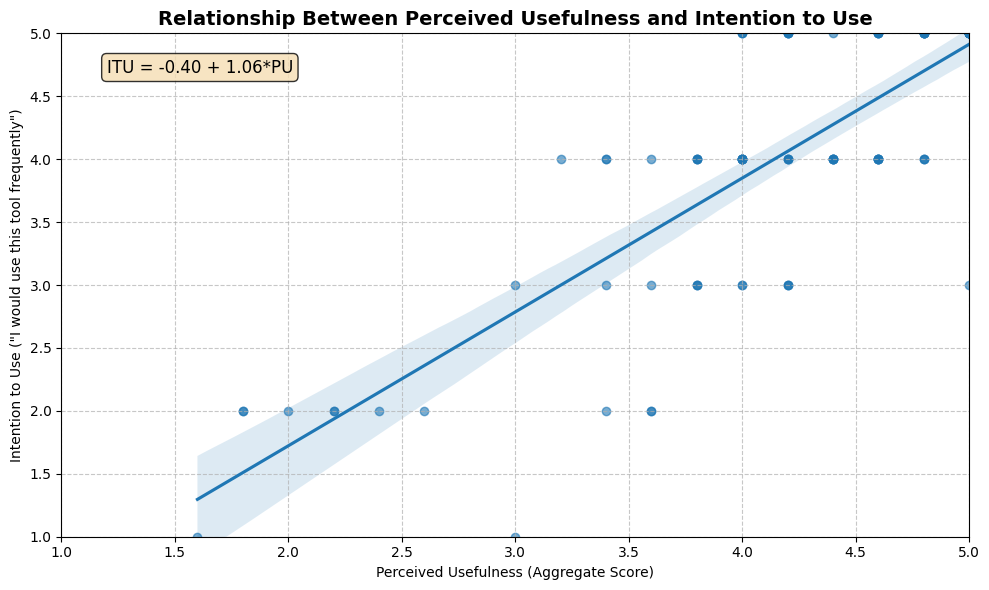

In [13]:
# --------------------------------------------------------------------
# Step 3: Print results and create a visualization
# --------------------------------------------------------------------

# Print the regression results
print(model.summary())
print("\n")
print("="*50)
print("KEY INSIGHTS:")
print(f"1. Relationship: For every 1-point increase in Perceived Usefulness (PU),")
print(f"   Intention to Use (ITU) increases by {model.params['PU']:.3f} points.")
print(f"2. Statistical Significance: The p-value for PU is {model.pvalues['PU']:.4f}.")
if model.pvalues['PU'] < 0.05:
    print("   This is a statistically significant relationship (p < 0.05).")
else:
    print("   This relationship is not statistically significant.")
print(f"3. Model Fit: The R-squared value is {model.rsquared:.3f}, meaning that")
print(f"   {model.rsquared*100:.1f}% of the variation in Intention to Use is explained by Perceived Usefulness.")
print("="*50)

# Create a scatter plot with regression line
plt.figure(figsize=(10, 6))
sns.regplot(x=df['PU'], y=df['ITU'], ci=95, scatter_kws={'alpha':0.6})
plt.title('Relationship Between Perceived Usefulness and Intention to Use', fontsize=14, fontweight='bold')
plt.xlabel('Perceived Usefulness (Aggregate Score)')
plt.ylabel('Intention to Use ("I would use this tool frequently")')
plt.ylim(1, 5)
plt.xlim(1, 5)
# Add the regression equation to the plot
equation_text = f'ITU = {model.params["const"]:.2f} + {model.params["PU"]:.2f}*PU'
plt.text(0.05, 0.95, equation_text, transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()